In [1]:
import numpy as np
import matplotlib.pyplot as plt



In [5]:
import pandas as pd

import pandas as pd

def xlsx_to_dict_of_arrays(filename):
    """
    Reads an Excel file and converts each sheet into a 2D NumPy array.
    
    Parameters
    ----------
    filename : str
        Path to the Excel file (.xlsx)
    
    Returns
    -------
    dict
        Dictionary mapping sheet_name -> 2D NumPy array
    """
    xls = pd.ExcelFile(filename)
    data_dict = {}

    for sheet_name in xls.sheet_names:
        # header=None ensures pandas doesn't try to use the first row as column names
        df = pd.read_excel(xls, sheet_name=sheet_name, header=None)
        data_dict[sheet_name] = df.to_numpy()
    
    return data_dict



In [6]:
data = xlsx_to_dict_of_arrays('VaryingSensorConfiguration.xlsx')

In [10]:
for key, val in data.items():
    print(f"{key}")

SS2in5mm5mm
DS1v1_2in5mm5mm
SS2in1cm1cm
DS1v1_2in1cm1cm
SS2in1cm6cm
DS1v1_2in1cm6cm
SS6mm5mm5mm
DS1v1_6mm5mm5mm
SS6mm1cm1cm
DS1v1_6mm1cm1cm
SS6mm1cm6cm
DS1v1_6mm1cm6cm


[[0.267004 0.004874 0.329415 1.      ]
 [0.127568 0.566949 0.550556 1.      ]
 [0.993248 0.906157 0.143936 1.      ]]


(20.0, 1000000.0)

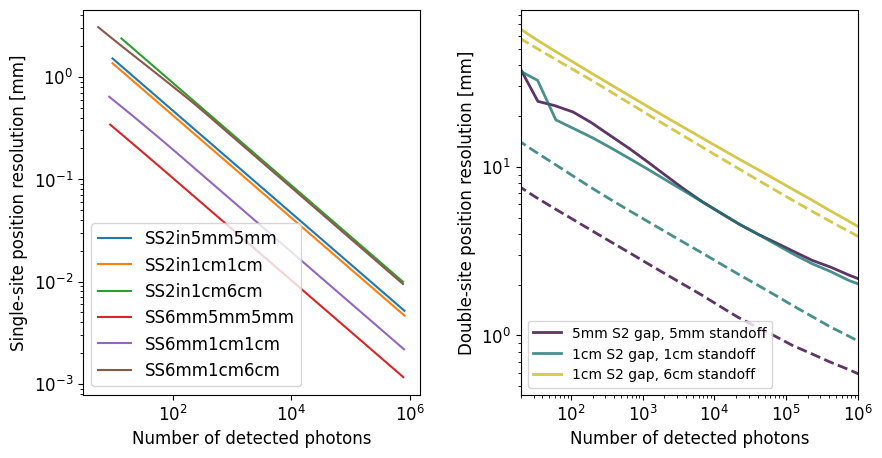

In [43]:
# Loop through dictionary and make a plot with two subfigures: the left panel has all curves whose keys start with "SS" and the right has all curves that start with "DS1v1"
colors = plt.cm.viridis(np.linspace(0, 1, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['figure.figsize'] = [12, 5]
# increase the spacing between subfigures
print(colors)

color_table = {'5mm': colors[0],
               '1cm': colors[1],
               '6cm': colors[2]}



fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plt.subplots_adjust(wspace=0.3)



for key, val in data.items():
    if key.startswith("SS"):
        axs[0].plot(val[:, 0], val[:, 1], label=key)
        
        
    elif key.startswith("DS1v1"):
        
        info_str = key.split('_')[1]  # Use only the part before the underscore as the label
        
        if '6mm' in info_str[0:3]:
            axs[1].plot(val[:, 0], val[:, 1]*10, '--', label='', color = color_table[info_str[6:9]]*0.8, linewidth=2)
        else:
            label = '{} S2 gap, {} standoff'.format(info_str[3:6], info_str[6:9])
            axs[1].plot(val[:, 0], val[:, 1]*10, color = color_table[info_str[6:9]]*0.8, label=label, linewidth=2)
        
        
        
axs[0].legend()
axs[0].set_yscale('log')
axs[0].set_xlabel('Number of detected photons')
axs[0].set_ylabel('Single-site position resolution [mm]')
axs[0].set_xscale('log')

axs[1].legend(fontsize=10, loc='lower left')
axs[1].set_yscale('log')
axs[1].set_xlabel('Number of detected photons')
axs[1].set_ylabel('Double-site position resolution [mm]')
axs[1].set_xscale('log')
axs[1].set_xlim(2e1, 1e6)
# Set axis labels to be qhole numbers, rather than scientific notation


In [152]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# Make text serif
plt.rcParams['font.family'] = 'serif'

def plot_resolution_curves(data):
    """
    Plot resolution curves from a dict of arrays.

    Left panel: curves with keys starting with "SS"
    Right panel: curves with keys starting with "DS1v1"

    Parameters
    ----------
    data : dict
        Dictionary mapping key -> 2D array (N, 2),
        where [:,0] is x and [:,1] is y.
    """
    # Set up colors
    colors = plt.cm.viridis(np.linspace(0, 1, 3))
    color_table = {
        '5mm': colors[0],
        '1cm': colors[1],
        '6cm': colors[2]
    }

    plt.rcParams.update({'font.size': 12})

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    plt.subplots_adjust(wspace=0.3)

    # Loop through dictionary and plot
    for key, val in data.items():
        if key.startswith("SS") or key.startswith("DS1v1"):
            if key.startswith("SS"):
                info_str = key.split('S')[2]
            else:
                info_str = key.split('_')[1]

            # Handle special 6mm case (dashed line, no label)
            if '6mm' in info_str[0:3]:
                linestyle = '--'
                label = ''
            else:
                linestyle = '-'
                label = '{} standoff'.format(info_str[6:9])

            color = color_table[info_str[6:9]] * 0.9

            if key.startswith("SS"):
                axs[0].plot(
                    val[:, 0], val[:, 1] ,
                    linestyle, color=color, label=label, linewidth=2
                )

            elif key.startswith("DS1v1"):
                axs[1].plot(
                    val[:, 0], val[:, 1] ,
                    linestyle, color=color, label=label, linewidth=2
                )

    # Function to convert standoff string to numeric mm
    def standoff_to_mm(s):
        # Take first word (numeric + unit)
        s = s.split()[0]
        if 'mm' in s:
            return float(s.replace('mm',''))
        elif 'cm' in s:
            return float(s.replace('cm','')) * 10
        else:
            return 0

    # Sort legend entries by standoff numerically for left subplot
    handles, labels = axs[0].get_legend_handles_labels()
    if labels:  # check for non-empty labels
        sorted_pairs = sorted(
            zip(labels, handles),
            key=lambda x: standoff_to_mm(x[0].split(',')[0])
        )
        labels, handles = zip(*sorted_pairs)
        axs[0].legend(handles, labels, fontsize=12, loc='upper right', frameon=False)

    # Sort legend entries by standoff numerically for right subplot
    handles, labels = axs[1].get_legend_handles_labels()
    if labels:
        sorted_pairs = sorted(
            zip(labels, handles),
            key=lambda x: standoff_to_mm(x[0].split(',')[0])
        )
        labels, handles = zip(*sorted_pairs)
        # axs[1].legend(handles, labels, fontsize=11, loc='lower left', frameon=False)

    # Axis formatting
    for ax in axs:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(20, 1e6)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}"))
        # ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}"))
        ax.tick_params(axis='both', which='major', labelsize=12)
        
    # Set y axis limits to nearest power of 10
    axs[0].set_ylim(0.01, 10)
    axs[1].set_ylim(0.01, 10)

    axs[0].set_xlabel('Number of detected photons')
    axs[0].set_ylabel('Single-site position resolution [cm]')
    axs[1].set_xlabel('Number of detected photons')
    axs[1].set_ylabel('Double-site position resolution [cm]')

    # Add text in top right of subplot 2
    axs[1].text(5e3, 7, "Dashed: 6mm sensor\nSolid: 2\" sensor",
                horizontalalignment='left', verticalalignment='top',
                fontsize=12, linespacing=1.5)

    plt.show()



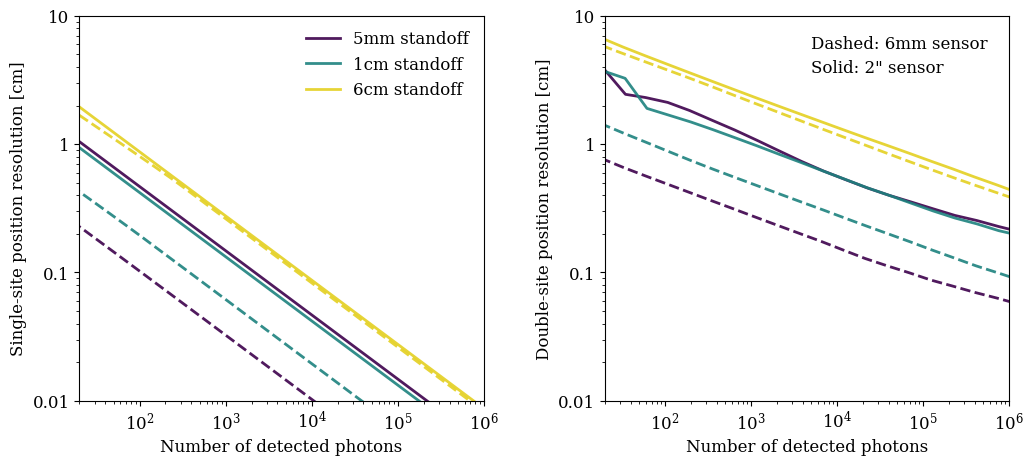

In [153]:
plot_resolution_curves(data)

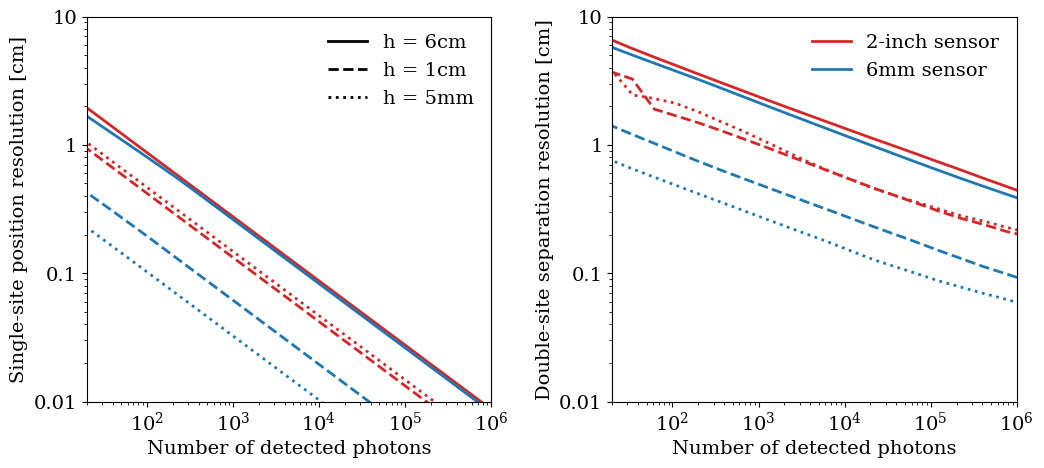

In [187]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# Make text serif
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['font.size'] = 14

def plot_resolution_curves(data):
    """
    Plot resolution curves from a dict of arrays.

    Left panel: curves with keys starting with "SS"
    Right panel: curves with keys starting with "DS1v1"

    Parameters
    ----------
    data : dict
        Dictionary mapping key -> 2D array (N, 2),
        where [:,0] is x and [:,1] is y.
    """
    # Set up colors
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    line_styles = {
        '5mm': ':',
        '1cm': '--',
        '6cm': '-'
    }
    
        # Create dummy lines for legend
    line_style_legend_lines = [
        Line2D([0], [0], color='black', linestyle=val, linewidth=2, label="h = " + key) for key, val in line_styles.items()
    ]
    
    # Reverse order
    line_style_legend_lines = [
        Line2D([0], [0], color='black', linestyle=val, linewidth=2, label="h = " + key)
        for key, val in reversed(list(line_styles.items()))
    ]


    plt.rcParams.update({'font.size': 12})

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    plt.subplots_adjust(wspace=0.3)

    # Loop through dictionary and plot
    for key, val in data.items():
        if key.startswith("SS") or key.startswith("DS1v1"):
            if key.startswith("SS"):
                info_str = key.split('S')[2]
            else:
                info_str = key.split('_')[1]

            # Handle special 6mm case (dashed line, no label)
            if '6mm' in info_str[0:3]:
                color=colors[0]
                label = ''
            else:
                color=colors[3]
                label = '{} standoff'.format(info_str[6:9])
                
            linestyle = line_styles[info_str[6:9]] 

            if key.startswith("SS"):
                axs[0].plot(
                    val[:, 0], val[:, 1] ,
                    linestyle, color=color, label=label, linewidth=2
                )

            elif key.startswith("DS1v1"):
                axs[1].plot(
                    val[:, 0], val[:, 1] ,
                    linestyle, color=color, label=label, linewidth=2
                )

    # Function to convert standoff string to numeric mm
    def standoff_to_mm(s):
        # Take first word (numeric + unit)
        s = s.split()[0]
        if 'mm' in s:
            return float(s.replace('mm',''))
        elif 'cm' in s:
            return float(s.replace('cm','')) * 10
        else:
            return 0

    # Sort legend entries by standoff numerically for left subplot
    handles, labels = axs[0].get_legend_handles_labels()
    if labels:  # check for non-empty labels
        sorted_pairs = sorted(
            zip(labels, handles),
            key=lambda x: standoff_to_mm(x[0].split(',')[0])
        )
        labels, handles = zip(*sorted_pairs)
        axs[0].legend(handles=line_style_legend_lines, fontsize=14, loc='upper right', frameon=False)


    # Axis formatting
    for ax in axs:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(20, 1e6)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}"))
        # ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}"))
        ax.tick_params(axis='both', which='major', labelsize=14)
        
    # Set y axis limits to nearest power of 10
    axs[0].set_ylim(0.01, 10)
    axs[1].set_ylim(0.01, 10)

    axs[0].set_xlabel('Number of detected photons', fontsize=14)
    axs[0].set_ylabel('Single-site position resolution [cm]', fontsize=14)
    axs[1].set_xlabel('Number of detected photons', fontsize=14)
    axs[1].set_ylabel('Double-site separation resolution [cm]', fontsize=14)

    # Dummy lines for the legend
    sensor_legend_lines = [
        Line2D([0], [0], color=colors[3], linestyle='-', linewidth=2, label='2-inch sensor'),
        Line2D([0], [0], color=colors[0], linestyle='-', linewidth=2, label='6mm sensor')
    ]

    # Add the legend to the right subplot
    axs[1].legend(handles=sensor_legend_lines, loc='upper right', frameon=False, fontsize=14)

    plt.savefig('resolution_vs_detected_photons_for_different_heights.pdf', bbox_inches='tight')


plot_resolution_curves(data)

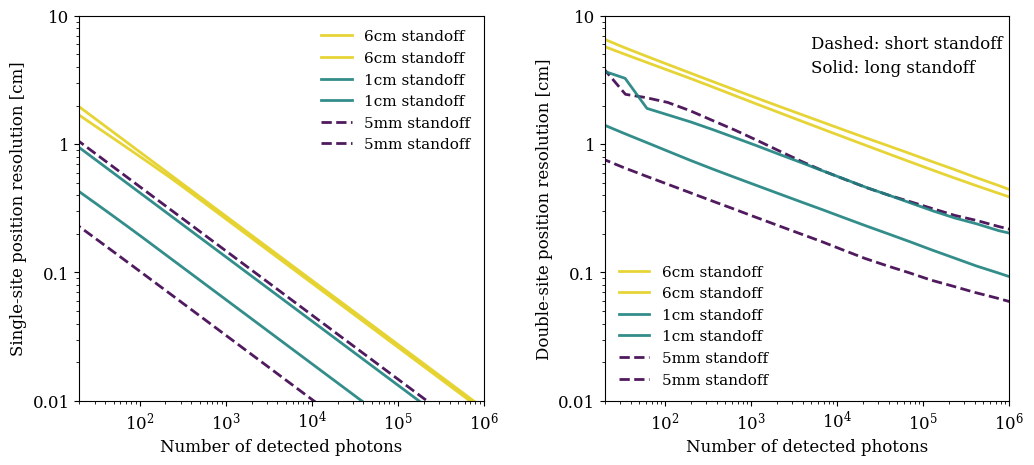

In [165]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'serif'

def plot_resolution_curves(data):
    """
    Plot resolution curves with:
    - Line style = standoff distance
    - Color = sensor size
    Legends:
    - Left panel: line style legend (standoff)
    - Right panel: color legend (sensor size)
    """
    # Colors for sensor sizes
    colors = plt.cm.viridis(np.linspace(0, 1, 3))
    color_table = {'5mm': colors[0], '1cm': colors[1], '6cm': colors[2]}

    # Line styles for standoff distances
    linestyle_table = {'short': '--', 'long': '-'}

    plt.rcParams.update({'font.size': 12})

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    plt.subplots_adjust(wspace=0.3)

    for key, val in data.items():
        if key.startswith("SS") or key.startswith("DS1v1"):
            if key.startswith("SS"):
                info_str = key.split('S')[2]
            else:
                info_str = key.split('_')[1]

            sensor = info_str[6:9]  # 5mm, 1cm, 6cm
            standoff_val = info_str[0:3]  # 6mm, 2cm, etc.

            # Map standoff to line style
            linestyle = linestyle_table['short'] if 'mm' in standoff_val else linestyle_table['long']
            color = color_table[sensor]

            label = f"{standoff_val}, {sensor}"

            ax = axs[0] if key.startswith("SS") else axs[1]
            ax.plot(val[:, 0], val[:, 1], linestyle=linestyle, color=color,
                    label=label, linewidth=2)

    # Axis formatting
    for ax in axs:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(20, 1e6)
        ax.set_ylim(0.01, 10)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}"))
        ax.tick_params(axis='both', which='major', labelsize=12)

    axs[0].set_xlabel('Number of detected photons')
    axs[0].set_ylabel('Single-site position resolution [cm]')
    axs[1].set_xlabel('Number of detected photons')
    axs[1].set_ylabel('Double-site position resolution [cm]')

    # Add text annotation
    axs[1].text(5e3, 7, "Line style = standoff distance", horizontalalignment='left',
                verticalalignment='top', fontsize=12, linespacing=1.5)

    # --- Line style legend for left panel ---
    standoff_legend_lines = [
        Line2D([0], [0], color='black', linestyle=linestyle_table['short'], linewidth=2, label='short standoff'),
        Line2D([0], [0], color='black', linestyle=linestyle_table['long'], linewidth=2, label='long standoff')
    ]
    standoff_legend = axs[0].legend(handles=standoff_legend_lines, loc='upper right',
                                    title='Standoff', frameon=False)

    # --- Color legend for right panel ---
    color_legend_lines = [
        Line2D([0], [0], color=color_table[sensor], linestyle='-', linewidth=2, label=sensor)
        for sensor in color_table
    ]
    axs[1].legend(handles=color_legend_lines, loc='upper right', title='Sensor', frameon=False)

    plt.show()


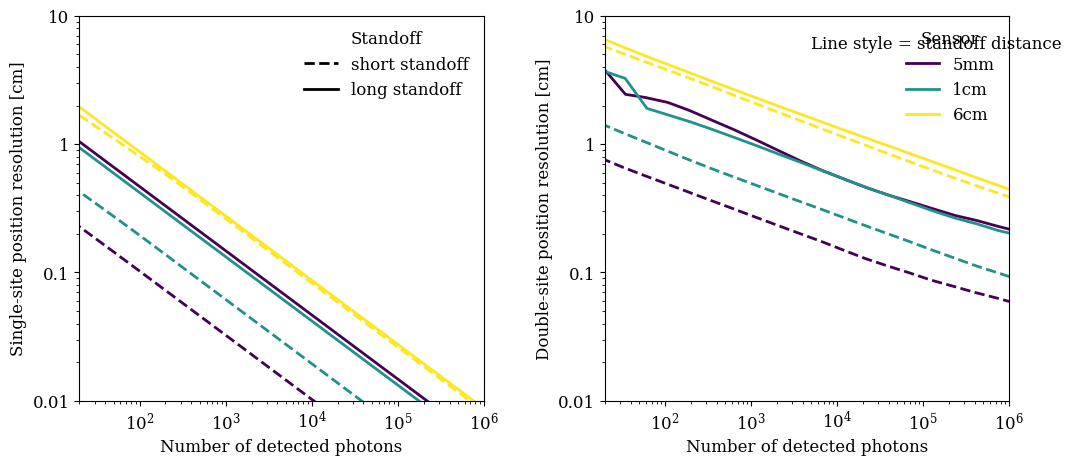

In [166]:
plot_resolution_curves(data)